In [ ]:
import os

import torch
import torch_geometric
import yaml
from lightning import seed_everything

from neat.model import MolGen

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Set device for model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# settings for deterministic generation
torch.set_float32_matmul_precision("medium")
torch_geometric.seed_everything(42)
seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


In [2]:
ROOT = "/data/sharedXL/projects/Daniel/MolGen/logs/MolGen/version_127"
CONFIG_FILE_PATH = os.path.join(ROOT, "hparams.yaml")
print(f"Using default config file: {CONFIG_FILE_PATH}")

# Generation configs
params = yaml.load(
    open(CONFIG_FILE_PATH, "r"),
    Loader=yaml.FullLoader,
)

# Checkpoints path (find the first .ckpt file in the checkpoints folder)
checkpoints_dir = os.path.join(ROOT, "checkpoints")
pt_files = [
    f
    for f in os.listdir(checkpoints_dir)
    if f.endswith(".ckpt") and f.startswith("best-val-validity")
]
if not pt_files:
    raise FileNotFoundError(f"No .ckpt files found in {checkpoints_dir}")

CHECKPOINTS_PATH = os.path.join(checkpoints_dir, pt_files[0])
print(f"Using checkpoint file: {CHECKPOINTS_PATH}")

# Load model
MODEL = MolGen
model = MODEL.load_from_checkpoint(CHECKPOINTS_PATH, map_location=device)

Using default config file: /data/sharedXL/projects/Daniel/MolGen/logs/MolGen/version_127/hparams.yaml
Using checkpoint file: /data/sharedXL/projects/Daniel/MolGen/logs/MolGen/version_127/checkpoints/best-val-validity-epoch=9749.ckpt
number of parameters: 164.70M


tensor([0.0000, 0.0323, 0.0640, 0.0952, 0.1259, 0.1560, 0.1856, 0.2147, 0.2433,
        0.2713, 0.2988, 0.3258, 0.3522, 0.3781, 0.4035, 0.4283, 0.4527, 0.4765,
        0.4997, 0.5225, 0.5447, 0.5664, 0.5875, 0.6081, 0.6282, 0.6478, 0.6668,
        0.6854, 0.7033, 0.7208, 0.7377, 0.7541, 0.7700, 0.7853, 0.8001, 0.8144,
        0.8281, 0.8414, 0.8540, 0.8662, 0.8778, 0.8889, 0.8995, 0.9096, 0.9191,
        0.9281, 0.9365, 0.9445, 0.9519, 0.9588, 0.9651, 0.9709, 0.9762, 0.9810,
        0.9852, 0.9889, 0.9921, 0.9947, 0.9968, 0.9984, 0.9995, 1.0000],
       device='cuda:0')

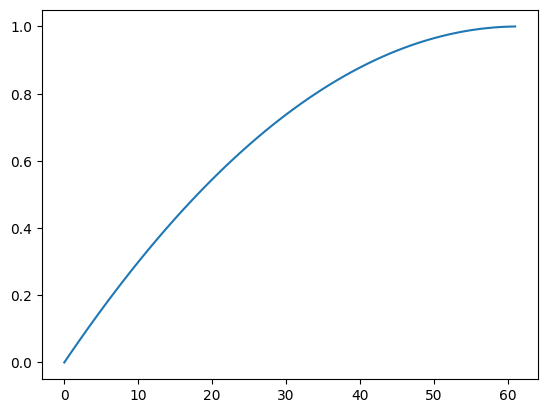

In [ ]:
import matplotlib.pyplot as plt

time_steps = torch.cumsum(torch.arange(61, 0, -1, device=device, dtype=torch.long), dim=0)
time_steps = torch.cat([torch.tensor([0], device=device), time_steps])
time_steps = time_steps / time_steps[-1]
plt.plot(time_steps.cpu().numpy())
time_steps

In [89]:
import torch.nn.functional as F
from torch import Tensor


def calculate_density(
    model,
    x_next: Tensor,
    source_set_representation: Tensor,
    grid: Tensor,
    num_time_steps: int,
    num_samples: int,
    device: torch.device,
) -> Tensor:
    """
    Method to calculate the positions of the newly predicted atoms with flow matching.

    Args:
        x_next (Tensor): The atom types of the newly predicted atoms. shape: [n_atoms, 1]
        source_set_representation (Tensor): The representation of the source sets. shape: [n_atoms, n_embd]
        num_time_steps (int): The number of time steps to use for the flow matching.
        device (torch.device): The device to use for computations.
        integration_method (str): The integration method to use for the flow matching.

    Returns:
        Tensor: The positions of the newly predicted atoms. shape: [n_atoms, 3]
    """
    # (1) Initialize next atoms' position with a random position
    positions = 1.4 * torch.randn((num_samples, 3), device=device)
    pos_trajectory = [positions.unsqueeze(0)]
    grid_velocity = model.compute_vector_field(
        x_next.expand(grid.shape[0]),
        grid,
        torch.zeros(grid.shape[0], device=device),
        source_set_representation.expand(grid.shape[0], -1),
        device=device,
    )
    grid_trajectory = [grid_velocity.unsqueeze(0)]
    #time_steps = torch.linspace(0, 1, num_time_steps, device=device)
    time_steps = torch.cumsum(torch.arange(61, 0, -1, device=device, dtype=torch.long), dim=0)
    time_steps = torch.cat([torch.tensor([0], device=device), time_steps])
    time_steps = time_steps / time_steps[-1]
    dts = time_steps[1:] - time_steps[:-1]

    for dt, time_step in zip(
        dts, time_steps[:-1]
    ):
        velocity = model.compute_vector_field(
            x_next.expand(num_samples),
            positions,
            time_step.expand(num_samples),
            source_set_representation.expand(num_samples, -1),
            device=device,
        )
        delta_pos = dt * velocity
        positions = positions + delta_pos
        pos_trajectory.append(positions.unsqueeze(0))
        grid_velocity = model.compute_vector_field(
            x_next.expand(grid.shape[0]),
            grid,
            (time_step + dt).expand(grid.shape[0]),
            source_set_representation.expand(grid.shape[0], -1),
            device=device,
        )
        grid_trajectory.append(grid_velocity.unsqueeze(0))

    pos_trajectory = torch.cat(pos_trajectory, dim=0)
    grid_trajectory = torch.cat(grid_trajectory, dim=0)

    return pos_trajectory, grid_trajectory


batch_size: int = 1
max_atoms: int = 100
num_time_steps: int = 61
num_samples: int = 1000

from tqdm import tqdm


x = torch.tensor([2], device=device)  # Example input tensor
pos = 1.4 * torch.randn((1, 3), device=device)
batch = torch.zeros_like(x, device=device)
axis = torch.linspace(-3, 3, steps=7)  # inclusive endpoints, step 0.5
grid = torch.cartesian_prod(axis, axis, axis)  # shape: (21*21*21, 3) = (9261, 3)
pos_trajectories = []
grid_trajectories = []

with torch.no_grad():
    model.eval()
    for i in tqdm(range(max_atoms)):
        source_set_representation = model.compute_source_set_representation(
            x, pos, batch, device
        )  # [active_mol_count, n_embd]

        # (6.2) Compute logits
        logits = model.atom_type_prediction_head(
            source_set_representation
        )  # [active_mol_count, vocab_size]

        # (6.3) Compute probabilities
        probabilities = F.softmax(logits, dim=-1)  # [active_mol_count, vocab_size]

        # (6.4) Sample next atom types from the resulting distribution
        x_next = torch.argmax(probabilities, dim=1)
        
        if x_next.item() == 0:  # Assuming 0 is the stop token
            print("Generation stopped.")
            break
        
        pos_trajectory, grid_trajectory = calculate_density(
            model, x_next, source_set_representation, grid, num_time_steps, num_samples, device
        )
        pos_next = pos_trajectory[-1, 0, :]
        pos_trajectories.append(pos_trajectory.unsqueeze(0))
        grid_trajectories.append(grid_trajectory.unsqueeze(0))
        x = torch.cat([x, x_next], dim=0)
        pos = torch.cat([pos, pos_next.unsqueeze(0)], dim=0)
        pos -= pos.mean(dim=0, keepdim=True)
        batch = torch.zeros_like(x, device=device)
        
pos_trajectories = torch.cat(pos_trajectories, dim=0)
grid_trajectories = torch.cat(grid_trajectories, dim=0)

 12%|█▏        | 12/100 [00:04<00:32,  2.71it/s]

Generation stopped.


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
from matplotlib import animation

def atom_label(atom_type_int):
    # Map 1..5 -> H,C,N,O,F
    mapping = {1: "H", 2: "C", 3: "N", 4: "O", 5: "F"}
    at = int(atom_type_int)
    return mapping.get(at, f"Type {at}")

def plot_autoregressive_build_3d(
    x,
    pos,
    pos_trajectories,
    step_indices=None,             # list[int] steps k to show; default: all (0..n-2)
    time_indices=None,             # list[int] timesteps to show; default: range(0, T, time_stride)
    time_stride=5,                 # used if time_indices is None (when not animating)
    sample_subsample=None,         # int or None: subsample the S samples per (k,t)
    point_size_samples=6,          # size for distribution samples
    alpha_samples=0.25,            # transparency for distribution samples
    point_size_atoms=50,           # size for prefix atoms
    figsize_per_panel=(3.0, 3.0),  # approximate size per subplot (width, height)
    equal_aspect=True,             # set equal data aspect (cube) per axes
    palette=None,                  # optional dict: {1:"...",2:"...",3:"...",4:"...",5:"..."}
    show_legend=True,              # show figure legend for atom types
    per_row_limits=False,          # keep global frame size equal across all panels
    view_elev=20,                  # 3D view elevation
    view_azim=-60,                 # 3D view azimuth
    sample_color="#1f77b4",        # color for samples
    zoom=1.0,

    # Vector field (quiver)
    grid=None,                     # (G, 3): starting points for arrows
    grid_trajectories=None,        # (n-1, T, G, 3): velocities per (step, time, grid_point)
    show_quiver=True,              # whether to render the vector field
    quiver_color="lightgray",      # color for arrows
    quiver_scale=1.0,              # scale factor applied to velocity vectors before plotting
    quiver_normalize=False,        # if True, normalize all arrows to the same length
    quiver_linewidth=0.8,          # linewidth for arrows

    # Animation
    make_gif=False,                # build an animation instead of static grid
    animate_mode="multirow",       # "multirow" (previous behavior) or "single" (one view, k then t)
    gif_path="molecule_build.gif", # output path for the GIF
    fps=20,                        # frames per second for GIF
    dpi=100,                       # DPI for saving GIF
):
    """
    x: array-like of length n with atom types in {1..5} (H,C,N,O,F)
    pos: array of shape (n, 3) with atom positions
    pos_trajectories: array of shape (n-1, T, S, 3)

    grid: array of shape (G, 3) with arrow starting points
    grid_trajectories: array of shape (n-1, T, G, 3) with velocity vectors

    Returns:
      - if make_gif=False: (fig, axes)
      - if make_gif=True:  (fig, axes, anim)
    """
    x = np.asarray(x)
    pos = np.asarray(pos)
    traj = np.asarray(pos_trajectories)

    assert pos.ndim == 2 and pos.shape[1] == 3, "pos must have shape (n, 3)"
    n = pos.shape[0]
    assert x.shape[0] == n, "x and pos length mismatch"
    assert traj.ndim == 4 and traj.shape[0] == n - 1 and traj.shape[-1] == 3, \
        "pos_trajectories must have shape (n-1, T, S, 3)"

    K = traj.shape[0]        # number of steps (n-1)
    T = traj.shape[1]        # time steps
    S = traj.shape[2]        # samples per (k, t)

    # Validate grid/quiver data if provided
    if show_quiver:
        if grid is None or grid_trajectories is None:
            raise ValueError("show_quiver=True requires both 'grid' and 'grid_trajectories'.")
        grid = np.asarray(grid)
        grid_traj = np.asarray(grid_trajectories)
        assert grid.ndim == 2 and grid.shape[1] == 3, "grid must have shape (G, 3)"
        assert grid_traj.shape == (n - 1, T, grid.shape[0], 3), \
            "grid_trajectories must have shape (n-1, T, G, 3)"
    else:
        grid = None
        grid_traj = None

    # Which steps to show (rows or sequence)
    if step_indices is None:
        step_indices = list(range(K))
    else:
        step_indices = [k for k in step_indices if 0 <= k < K]
        if len(step_indices) == 0:
            raise ValueError("No valid step_indices within [0, n-2].")

    # Which times to show
    if make_gif:
        # Use all timesteps for the animation
        full_time_indices = list(range(T))
    else:
        if time_indices is None:
            time_indices = list(range(0, T, max(1, int(time_stride))))
        else:
            time_indices = [t for t in time_indices if 0 <= t < T]
            if len(time_indices) == 0:
                raise ValueError("No valid time_indices within [0, T-1].")

    # Optional subsampling of samples
    if sample_subsample is not None:
        sample_subsample = int(sample_subsample)
        if sample_subsample <= 0:
            sample_subsample = None

    # Colors for atom types (1..5)
    default_palette = {
        1: "#FFFFFF",  # H
        2: "#000000",  # C
        3: "#0048FF",  # N
        4: "#FF0D0D",  # O
        5: "#00FF15",  # F
    }
    pal = palette if palette is not None else default_palette

    # Layout
    if make_gif and animate_mode == "single":
        n_rows, n_cols = 1, 1
    else:
        n_rows = len(step_indices)
        n_cols = 1 if make_gif else len(time_indices)

    # Create figure
    fig_w = max(1, n_cols) * figsize_per_panel[0]
    fig_h = max(1, n_rows) * figsize_per_panel[1]
    fig = plt.figure(figsize=(fig_w, fig_h))

    # Prepare axes grid of 3D subplots
    axes = np.empty((n_rows, n_cols), dtype=object)
    for i in range(n_rows):
        for j in range(n_cols):
            ax = fig.add_subplot(n_rows, n_cols, i * n_cols + j + 1, projection='3d')
            ax.view_init(elev=view_elev, azim=view_azim)
            axes[i, j] = ax

    # Compute bounds (always global across selected steps and all timesteps)
    def compute_bounds_for_steps(step_ids, time_ids):
        xs, ys, zs = [], [], []
        for k in step_ids:
            # prefix atoms
            prefix = pos[:k+1, :]
            if prefix.size > 0:
                xs.append(prefix[:, 0]); ys.append(prefix[:, 1]); zs.append(prefix[:, 2])

            for t in time_ids:
                samples = traj[k, t, :, :]
                if sample_subsample is not None and sample_subsample < S:
                    idx = np.random.choice(S, size=sample_subsample, replace=False)
                    samples = samples[idx]
                xs.append(samples[:, 0]); ys.append(samples[:, 1]); zs.append(samples[:, 2])

                if show_quiver:
                    starts = grid
                    vecs = grid_traj[k, t, :, :] * float(quiver_scale)
                    ends = starts + vecs
                    xs.append(starts[:, 0]); ys.append(starts[:, 1]); zs.append(starts[:, 2])
                    xs.append(ends[:, 0]);   ys.append(ends[:, 1]);   zs.append(ends[:, 2])

        xs = np.concatenate(xs) if len(xs) else np.array([0.0])
        ys = np.concatenate(ys) if len(ys) else np.array([0.0])
        zs = np.concatenate(zs) if len(zs) else np.array([0.0])

        # Padding
        def pad(lo, hi):
            span = hi - lo + 1e-9
            p = 0.05 * span
            return lo - p, hi + p

        xlim = pad(xs.min(), xs.max())
        ylim = pad(ys.min(), ys.max())
        zlim = pad(zs.min(), zs.max())

        if equal_aspect:
            min_all = min(xlim[0], ylim[0], zlim[0]) * zoom
            max_all = max(xlim[1], ylim[1], zlim[1]) * zoom
            center = (min_all + max_all) / 2.0
            half = (max_all - min_all) / 2.0
            xlim = (center - half, center + half)
            ylim = (center - half, center + half)
            zlim = (center - half, center + half)
        return xlim, ylim, zlim

    global_bounds = compute_bounds_for_steps(step_indices, list(range(T)))

    # ------------ Static rendering (non-animated) ------------
    if not make_gif:
        for i, k in enumerate(step_indices):
            prefix_pos = pos[:k+1, :]
            types_prefix = x[:k+1]
            predicted_atom_type = x[k+1] if (k + 1) < n else x[-1]
            
            for j, t in enumerate(time_indices):
                ax = axes[i, j]
                # samples
                samples = traj[k, t, :, :]
                if sample_subsample is not None and sample_subsample < S:
                    idx = np.random.choice(S, size=sample_subsample, replace=False)
                    samples = samples[idx]
                ax.scatter(
                    samples[:, 0], samples[:, 1], samples[:, 2],
                    s=point_size_samples, alpha=alpha_samples,
                    c=sample_color, depthshade=False
                )
                # Next atom (predicted)
                next_pos = traj[k, t, 0, :] 
                ax.scatter(
                    next_pos[0], next_pos[1], next_pos[2],
                    s=point_size_atoms, marker='D',
                    c=pal.get(int(predicted_atom_type), "#000000"),
                    edgecolors='limegreen', linewidths=1.5, depthshade=False
                )
                # prefix atoms
                for atom_type in np.unique(types_prefix):
                    mask = (types_prefix == atom_type)
                    ax.scatter(
                        prefix_pos[mask, 0], prefix_pos[mask, 1], prefix_pos[mask, 2],
                        s=point_size_atoms, 
                        c=pal.get(int(atom_type), "#000000"),
                        edgecolors='k', linewidths=1.0 if atom_type == 1 else 0., depthshade=False
                    )
                # quiver
                if show_quiver:
                    starts = grid
                    vecs = grid_traj[k, t, :, :] * float(quiver_scale)
                    ax.quiver(
                        starts[:, 0], starts[:, 1], starts[:, 2],
                        vecs[:, 0], vecs[:, 1], vecs[:, 2],
                        length=1.0, normalize=bool(quiver_normalize),
                        color=quiver_color, linewidth=quiver_linewidth
                    )
                if i == 0:
                    ax.set_title(f"t = {t}")

                xlim, ylim, zlim = global_bounds
                ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
                if equal_aspect:
                    ax.set_box_aspect((1, 1, 1))
                ax.grid(False)
                ax.set_axis_off()
                for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
                    try:
                        axis.pane.set_facecolor((1, 1, 1, 0))
                        axis.pane.set_edgecolor((1, 1, 1, 0))
                    except Exception:
                        pass
                ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
                ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")

        if show_legend:
            from matplotlib.lines import Line2D
            handles = []
            labels = []
            for ttype in sorted(set(x.tolist())):
                handles.append(Line2D([0], [0], marker='o', color='w',
                                      markerfacecolor=pal.get(int(ttype), "#000000"),
                                      markeredgecolor='k', markersize=8,
                                      label=atom_label(ttype)))
                labels.append(atom_label(ttype))
            fig.legend(handles=handles, labels=labels, loc="upper right", title="Atom types")

        plt.tight_layout(rect=(0, 0, 0.98, 1))
        return fig, axes

    # ------------ Animation: SINGLE VIEW mode ------------
    elif animate_mode == "single":
        ax = axes[0, 0]

        # state to track and update prefix, quiver, next atom
        state = {
            "last_k": None,
            "prefix_handles": [],
            "quiver_handle": None,
            "next_handle": None,  # predicted next atom (diamond)
        }

        # helper to (re)draw prefix atoms for step k
        def draw_prefix(k):
            # remove old
            for h in state["prefix_handles"]:
                try:
                    h.remove()
                except Exception:
                    pass
            state["prefix_handles"].clear()
            # draw new
            prefix_pos = pos[:k+1, :]
            types_prefix = x[:k+1]

            for atom_type in np.unique(types_prefix):
                mask = (types_prefix == atom_type)
                h = ax.scatter(
                    prefix_pos[mask, 0], prefix_pos[mask, 1], prefix_pos[mask, 2],
                    s=point_size_atoms,
                    c=pal.get(int(atom_type), "#000000"),
                    edgecolors='k', linewidths=1.0 if atom_type == 1 else 0., depthshade=False
                )
                state["prefix_handles"].append(h)
            state["last_k"] = k

        # initial draw for k=step_indices[0], t=0
        k0 = step_indices[0]
        draw_prefix(k0)

        samples0 = traj[k0, 0, :, :]
        if sample_subsample is not None and sample_subsample < S:
            idx = np.random.choice(S, size=sample_subsample, replace=False)
            samples0 = samples0[idx]
        scat = ax.scatter(
            samples0[:, 0], samples0[:, 1], samples0[:, 2],
            s=point_size_samples, alpha=alpha_samples,
            c=sample_color, depthshade=False
        )

        # initial quiver
        if show_quiver:
            starts = grid
            vecs0 = grid_traj[k0, 0, :, :] * float(quiver_scale)
            state["quiver_handle"] = ax.quiver(
                starts[:, 0], starts[:, 1], starts[:, 2],
                vecs0[:, 0], vecs0[:, 1], vecs0[:, 2],
                length=1.0, normalize=bool(quiver_normalize),
                color=quiver_color, linewidth=quiver_linewidth
            )

        # initial predicted next atom (diamond)
        predicted_atom_type0 = x[k0 + 1] if (k0 + 1) < n else x[-1]
        next_pos0 = traj[k0, 0, 0, :]
        state["next_handle"] = ax.scatter(
            [next_pos0[0]], [next_pos0[1]], [next_pos0[2]],
            s=point_size_atoms,
            c=pal.get(int(predicted_atom_type0), "#000000"),
            edgecolors='magenta', linewidths=1.5, depthshade=False
        )

        # global limits and styling
        xlim, ylim, zlim = global_bounds
        ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
        if equal_aspect:
            ax.set_box_aspect((1, 1, 1))
        ax.grid(False)
        ax.set_axis_off()
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            try:
                axis.pane.set_facecolor((1, 1, 1, 0))
                axis.pane.set_edgecolor((1, 1, 1, 0))
            except Exception:
                pass
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
        plt.tight_layout(rect=(0, 0, 0.9, 1))

        total_frames = len(step_indices) * T

        def update(frame):
            # map linear frame -> (k_index, t)
            k_index = frame // T
            t = frame % T
            k = step_indices[k_index]

            ax.set_title(f"step k = {k}, t = {t}")

            # update prefix if k changed
            k_changed = (state["last_k"] != k)
            if k_changed:
                draw_prefix(k)

            # update samples
            samples = traj[k, t, :, :]
            if sample_subsample is not None and sample_subsample < S:
                idx = np.random.choice(S, size=sample_subsample, replace=False)
                samples = samples[idx]
            scat._offsets3d = (samples[:, 0], samples[:, 1], samples[:, 2])

            # update quiver
            if show_quiver:
                if state["quiver_handle"] is not None:
                    try:
                        state["quiver_handle"].remove()
                    except Exception:
                        pass
                starts = grid
                vecs = grid_traj[k, t, :, :] * float(quiver_scale)
                state["quiver_handle"] = ax.quiver(
                    starts[:, 0], starts[:, 1], starts[:, 2],
                    vecs[:, 0], vecs[:, 1], vecs[:, 2],
                    length=1.0, normalize=bool(quiver_normalize),
                    color=quiver_color, linewidth=quiver_linewidth
                )

            # update predicted next atom
            next_pos = traj[k, t, 0, :]
            if k_changed:
                # predicted atom type can change with k -> recreate with new color
                predicted_atom_type = x[k + 1] if (k + 1) < n else x[-1]
                if state["next_handle"] is not None:
                    try:
                        state["next_handle"].remove()
                    except Exception:
                        pass
                state["next_handle"] = ax.scatter(
                    [next_pos[0]], [next_pos[1]], [next_pos[2]],
                    s=point_size_atoms,
                    c=pal.get(int(predicted_atom_type), "#000000"),
                    edgecolors='magenta', linewidths=1.5, depthshade=False
                )
            else:
                # same k -> only move the position
                state["next_handle"]._offsets3d = ([next_pos[0]], [next_pos[1]], [next_pos[2]])

            return []

        anim = animation.FuncAnimation(
            fig, update, frames=list(range(total_frames)),
            interval=1000.0 / float(fps), blit=False
        )

    else:
        raise ValueError("animate_mode must be 'multirow' or 'single'")

    # Legend for GIF
    if show_legend:
        from matplotlib.lines import Line2D
        handles = []
        labels = []
        for ttype in sorted(set(x.tolist())):
            handles.append(Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=pal.get(int(ttype), "#000000"),
                                  markeredgecolor='k', markersize=8,
                                  label=atom_label(ttype)))
            labels.append(atom_label(ttype))
        fig.legend(handles=handles, labels=labels, loc="lower right", title="Atom types")

    # Save GIF
    anim.save(gif_path, writer="pillow", fps=int(fps), dpi=int(dpi))
    return fig, axes

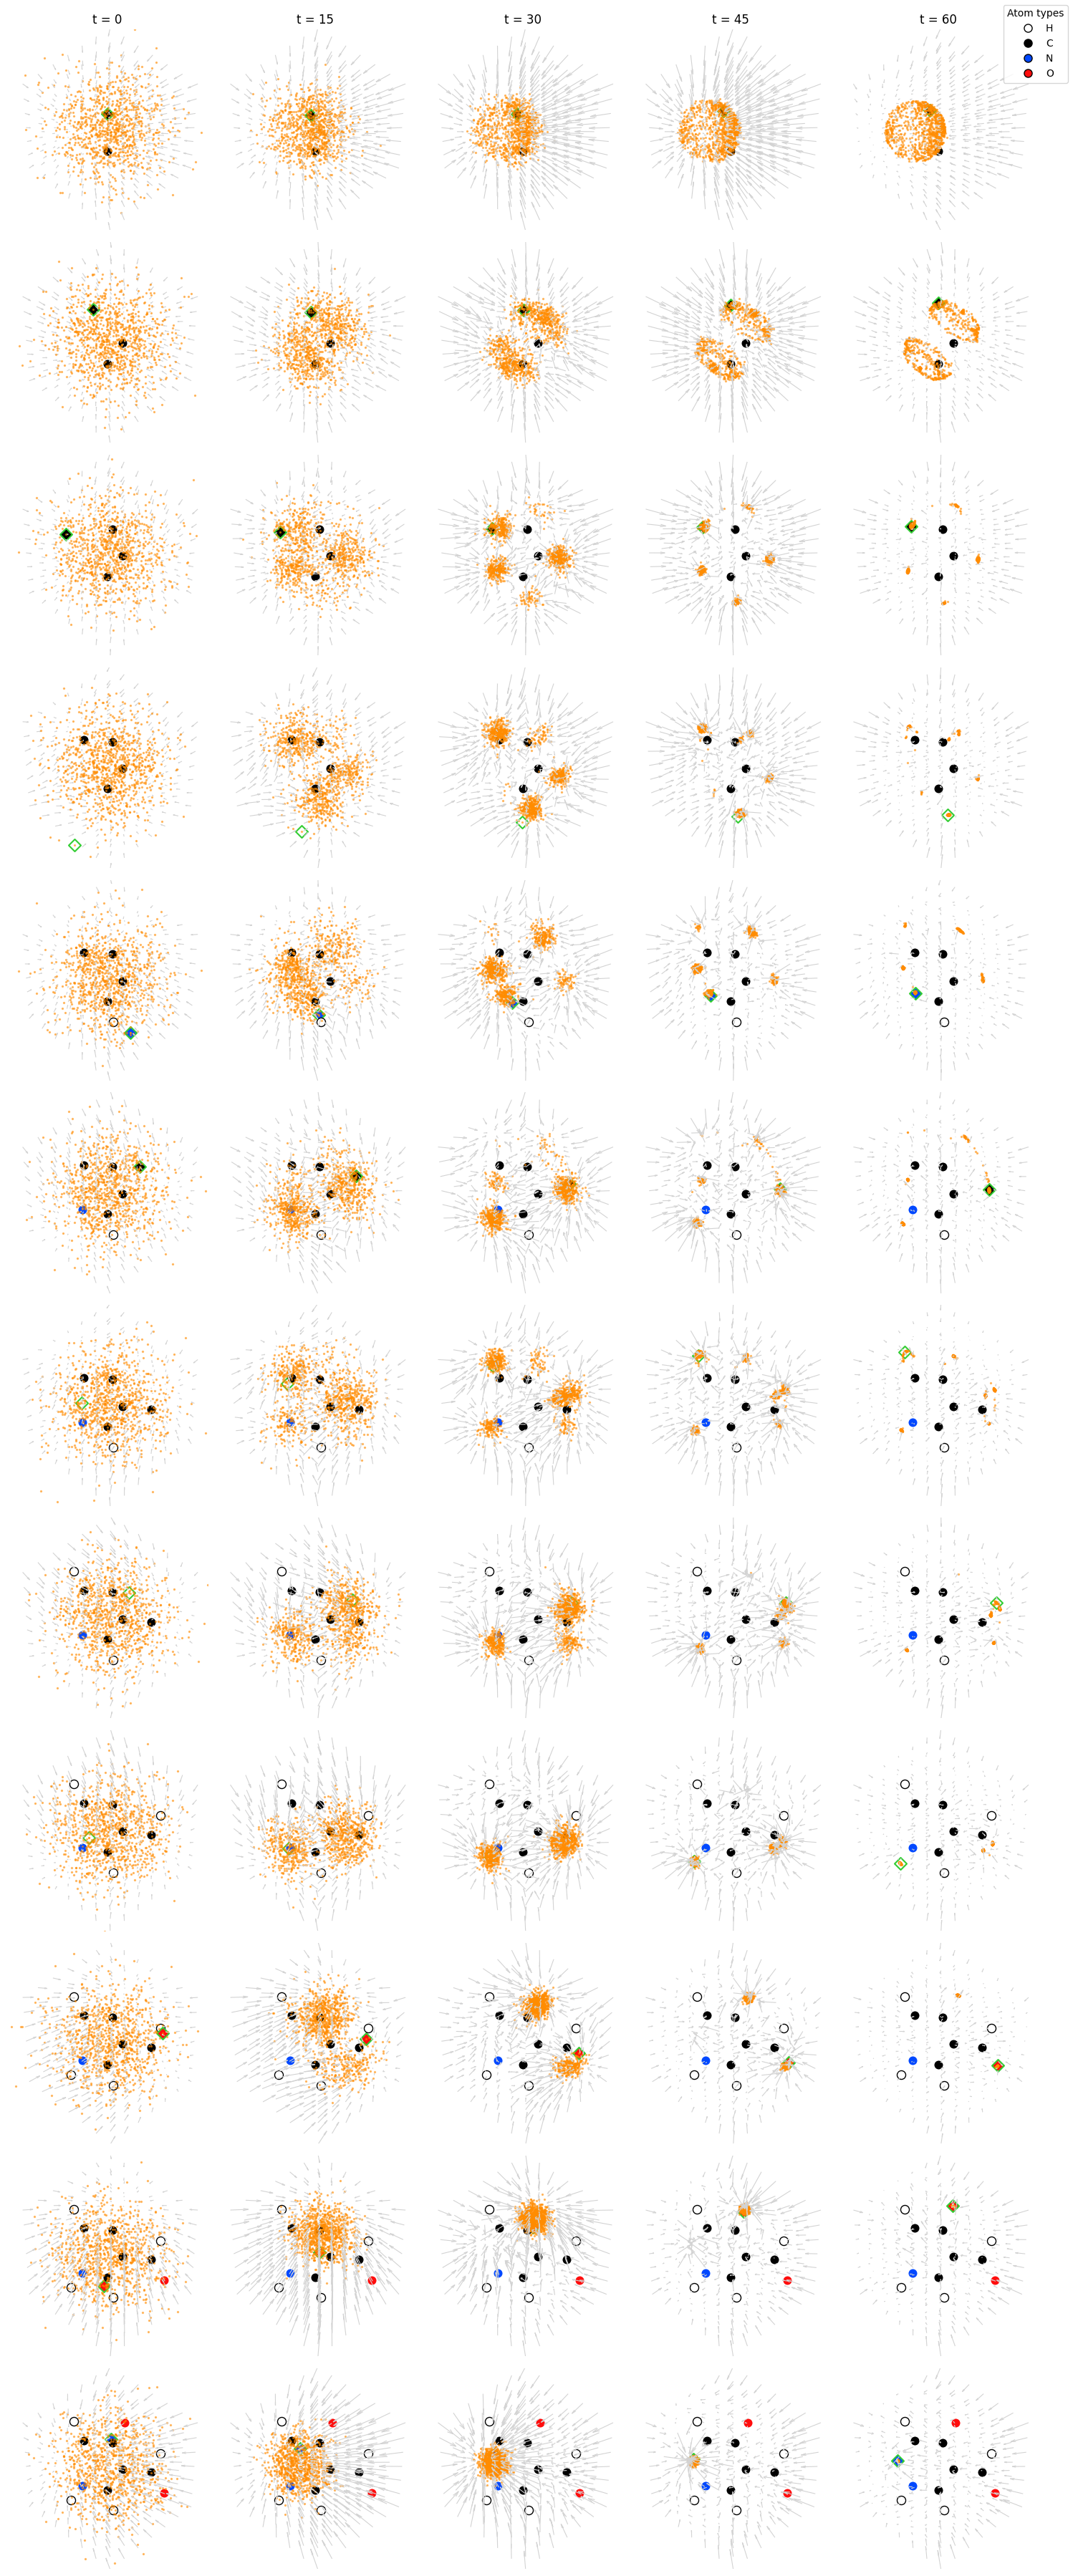

In [99]:
# All steps, every 5th timestep, subsample samples for speed
fig, axes = plot_autoregressive_build_3d(
    x=x.cpu(),
    pos=pos.cpu(),
    pos_trajectories=pos_trajectories.cpu(),
    time_stride=15,
    view_elev=45,
    view_azim=45,
    alpha_samples=0.5,
    zoom=0.5,
    point_size_samples=2,
    point_size_atoms=75,
    sample_color="darkorange",
    grid=grid.cpu(), 
    grid_trajectories=grid_trajectories.cpu(),
    quiver_normalize=False,
    quiver_scale=0.1,
    #make_gif=True,
    #gif_path="molecule_build.gif",
    #animate_mode="single",
    #dpi=300,
)
#plt.show()
plt.savefig("molecule_build.png", dpi=100)